In [51]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from transformers import pipeline
import time
import numpy as np
import nltk
from nltk.corpus import stopwords

In [44]:
from datasets import load_dataset
from datasets import DatasetDict
df = load_dataset("seara/ru_go_emotions", 'simplified')

In [43]:
df


DatasetDict({
    train: Dataset({
        features: ['ru_text', 'text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['ru_text', 'text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['ru_text', 'text', 'labels', 'id'],
        num_rows: 5427
    })
})

In [46]:
print(df['train'][0])
print(df['validation'][0])
print(df['test'][0])

{'ru_text': 'Моя любимая еда — это все, что мне не приходилось готовить самому.', 'text': "My favourite food is anything I didn't have to cook myself.", 'labels': [27], 'id': 'eebbqej'}
{'ru_text': 'Это в Новом Орлеане?? Я действительно чувствую, что это Новый Орлеан.', 'text': 'Is this in New Orleans?? I really feel like this is New Orleans.', 'labels': [27], 'id': 'edgurhb'}
{'ru_text': 'Мне очень жаль, что у вас сложилась ситуация :( Хотя мне нравятся имена Сапфира, Цирилла и Скарлетт!', 'text': 'I’m really sorry about your situation :( Although I love the names Sapphira, Cirilla, and Scarlett!', 'labels': [25], 'id': 'eecwqtt'}


In [ ]:
def preprocess_labels(dataset_dict):
    def process_labels(example):
        if isinstance(example['labels'], list) and len(example['labels']) > 0:
            example['labels'] = int(example['labels'][0])
        return example

    for split in dataset_dict.keys():
        dataset_dict[split] = dataset_dict[split].map(process_labels)
    return dataset_dict

df = preprocess_labels(df)

print(df['train'][0])
print(df['validation'][0])
print(df['test'][0])

Map: 100%|██████████| 5427/5427 [00:01<00:00, 3558.01 examples/s]

{'ru_text': 'Моя любимая еда — это все, что мне не приходилось готовить самому.', 'text': "My favourite food is anything I didn't have to cook myself.", 'labels': 27, 'id': 'eebbqej'}
{'ru_text': 'Это в Новом Орлеане?? Я действительно чувствую, что это Новый Орлеан.', 'text': 'Is this in New Orleans?? I really feel like this is New Orleans.', 'labels': 27, 'id': 'edgurhb'}
{'ru_text': 'Мне очень жаль, что у вас сложилась ситуация :( Хотя мне нравятся имена Сапфира, Цирилла и Скарлетт!', 'text': 'I’m really sorry about your situation :( Although I love the names Sapphira, Cirilla, and Scarlett!', 'labels': 25, 'id': 'eecwqtt'}


In [ ]:
df_train = df['train'].to_pandas()
df_test = pd.concat([df['test'].to_pandas(), df['validation'].to_pandas()], axis=0)

label_names = ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity',
        'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear',
        'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief',
        'remorse', 'sadness', 'surprise', 'neutral']
label_dict = {i: name for i, name in enumerate(label_names)}

X_train_text = df_train['ru_text']
y_train = df_train['labels']
X_test_text = df_test['ru_text']
y_test = df_test['labels']

print(f"Размер обучающей выборки: {len(df_train)}")
print(f"Размер тестовой выборки: {len(df_test)}")
print(f"Пример текста: {X_train_text.iloc[0]}")
print(f"Метка примера: {y_train.iloc[0]} ({label_dict[y_train.iloc[0]]})")
print(f"Все {len(label_names)} меток: {label_names}")

Размер обучающей выборки: 43410
Размер тестовой выборки: 10853
Пример текста: Моя любимая еда — это все, что мне не приходилось готовить самому.
Метка примера: 27 (neutral)
Все 28 меток: ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


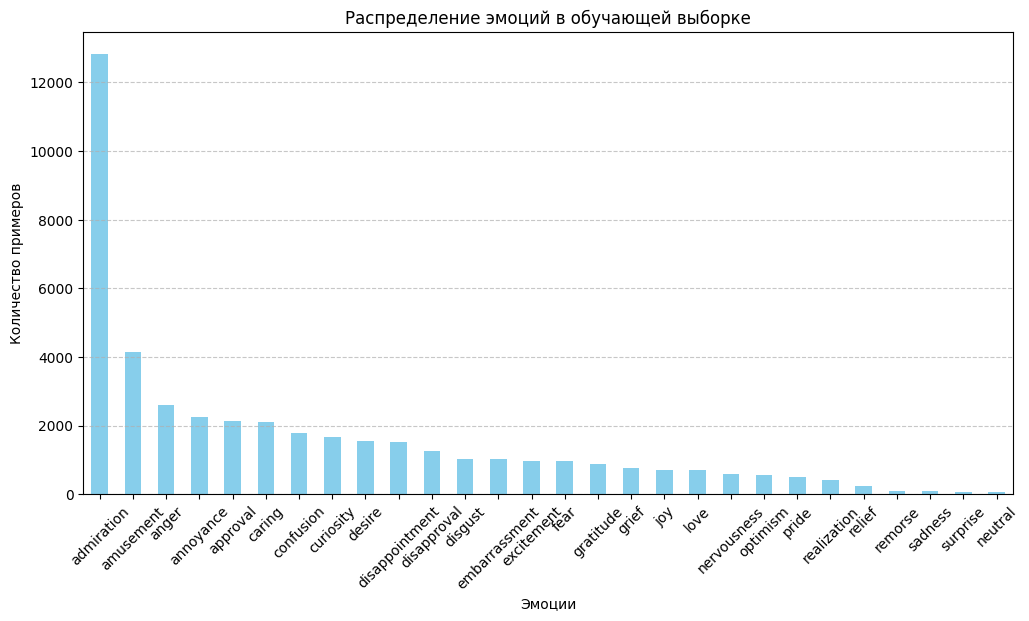

In [59]:
import matplotlib.pyplot as plt

# Подсчёт количества примеров для каждой эмоции
emotion_counts = y_train.value_counts()

# Визуализация распределения эмоций
plt.figure(figsize=(12, 6))
emotion_counts.plot(kind='bar', color='skyblue')
plt.title('Распределение эмоций в обучающей выборке')
plt.xlabel('Эмоции')
plt.ylabel('Количество примеров')
plt.xticks(ticks=range(len(label_names)), labels=[label_dict[i] for i in range(len(label_names))], rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [66]:
# Удаление классов с количеством примеров меньше 1000
classes_to_keep = emotion_counts[emotion_counts >= 1000].index
df_train_filtered = df_train[df_train['labels'].isin(classes_to_keep)]
df_test_filtered = df_test[df_test['labels'].isin(classes_to_keep)]

# Обновление X и y после фильтрации
X_train_text = df_train_filtered['ru_text']
y_train = df_train_filtered['labels']
X_test_text = df_test_filtered['ru_text']
y_test = df_test_filtered['labels']

# Обновление списка меток после фильтрации
filtered_labels = sorted(classes_to_keep)  # Сортируем оставшиеся классы
filtered_label_names = [label_dict[label] for label in filtered_labels]

# Вывод информации после фильтрации
print(f"Размер обучающей выборки после фильтрации: {len(df_train_filtered)}")
print(f"Размер тестовой выборки после фильтрации: {len(df_test_filtered)}")

Размер обучающей выборки после фильтрации: 35839
Размер тестовой выборки после фильтрации: 8941


In [67]:
nltk.download('stopwords')

russian_stop_words = stopwords.words('russian')

tfidf_vectorizer = TfidfVectorizer(max_features=5000, stop_words=russian_stop_words)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)

results = {}

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/andreyserba/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [68]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test_true):
    print(f"Обучение модели: {name}")
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    print(f"Предсказание модели: {name}")
    start_time = time.time()
    y_pred = model.predict(X_test)
    pred_time = time.time() - start_time

    accuracy = accuracy_score(y_test_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test_true, y_pred, average='weighted')

    print(f"Результаты для {name}:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision (weighted): {precision:.4f}")
    print(f"  Recall (weighted): {recall:.4f}")
    print(f"  F1-score (weighted): {f1:.4f}")
    print(f"  Время обучения: {train_time:.2f} сек")
    print(f"  Время предсказания: {pred_time:.2f} сек (на {len(y_test_true)} примерах)")
    print(classification_report(y_test_true, y_pred, target_names=filtered_label_names, zero_division=0))
    print()
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1,
            "train_time": train_time, "pred_time": pred_time / len(y_test_true)}

In [69]:
results['SVM'] = evaluate_model('SVM', SVC(kernel='linear'), X_train_tfidf, y_train, X_test_tfidf, y_test)

Обучение модели: SVM
Предсказание модели: SVM
Результаты для SVM:
  Accuracy: 0.5593
  Precision (weighted): 0.5522
  Recall (weighted): 0.5593
  F1-score (weighted): 0.4929
  Время обучения: 152.44 сек
  Время предсказания: 17.79 сек (на 8941 примерах)
                precision    recall  f1-score   support

    admiration       0.64      0.55      0.59       992
     amusement       0.76      0.76      0.76       549
         anger       0.49      0.26      0.34       389
     annoyance       0.46      0.11      0.18       533
      approval       0.48      0.11      0.18       673
     confusion       0.38      0.12      0.18       275
     curiosity       0.62      0.09      0.16       438
disappointment       0.38      0.07      0.11       256
   disapproval       0.45      0.02      0.04       466
     gratitude       0.82      0.85      0.84       585
           joy       0.57      0.34      0.42       237
          love       0.53      0.74      0.62       350
       neutral   

In [55]:
# Использую нелнейное ядро в SVM и сбалансированными весами классов
results['SVM_Balanced'] = evaluate_model('SVM (Balanced)', SVC(kernel='rbf', class_weight='balanced'), X_train_tfidf, y_train, X_test_tfidf, y_test)

Обучение модели: SVM (Balanced)
Предсказание модели: SVM (Balanced)
Результаты для SVM (Balanced):
  Accuracy: 0.4162
  Precision (weighted): 0.4220
  Recall (weighted): 0.4162
  F1-score (weighted): 0.4147
  Время обучения: 693.58 сек
  Время предсказания: 45.87 сек (на 10853 примерах)
                precision    recall  f1-score   support

    admiration       0.61      0.39      0.47       992
     amusement       0.76      0.69      0.72       549
         anger       0.34      0.28      0.31       389
     annoyance       0.19      0.19      0.19       533
      approval       0.24      0.20      0.22       673
        caring       0.30      0.30      0.30       252
     confusion       0.21      0.26      0.23       275
     curiosity       0.25      0.21      0.23       438
        desire       0.30      0.50      0.37       138
disappointment       0.11      0.10      0.11       256
   disapproval       0.15      0.18      0.17       466
       disgust       0.31      0.31    

In [56]:
results["Naive Bayes"] = evaluate_model("Naive Bayes", MultinomialNB(), X_train_tfidf, y_train, X_test_tfidf, y_test)

Обучение модели: Naive Bayes
Предсказание модели: Naive Bayes
Результаты для Naive Bayes:
  Accuracy: 0.3851
  Precision (weighted): 0.4773
  Recall (weighted): 0.3851
  F1-score (weighted): 0.2767
  Время обучения: 0.11 сек
  Время предсказания: 0.01 сек (на 10853 примерах)
                precision    recall  f1-score   support

    admiration       0.51      0.46      0.49       992
     amusement       0.75      0.27      0.39       549
         anger       0.59      0.08      0.14       389
     annoyance       0.19      0.01      0.01       533
      approval       0.49      0.04      0.07       673
        caring       0.54      0.03      0.05       252
     confusion       1.00      0.01      0.02       275
     curiosity       0.65      0.03      0.06       438
        desire       0.00      0.00      0.00       138
disappointment       0.00      0.00      0.00       256
   disapproval       0.00      0.00      0.00       466
       disgust       0.71      0.03      0.06      

/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [57]:
results["KNN"] = evaluate_model("KNN", KNeighborsClassifier(n_neighbors=5), X_train_tfidf, y_train, X_test_tfidf, y_test)

Обучение модели: KNN
Предсказание модели: KNN
Результаты для KNN:
  Accuracy: 0.3487
  Precision (weighted): 0.3485
  Recall (weighted): 0.3487
  F1-score (weighted): 0.2827
  Время обучения: 0.05 сек
  Время предсказания: 13.88 сек (на 10853 примерах)
                precision    recall  f1-score   support

    admiration       0.42      0.30      0.35       992
     amusement       0.57      0.27      0.37       549
         anger       0.30      0.16      0.21       389
     annoyance       0.14      0.04      0.06       533
      approval       0.22      0.07      0.10       673
        caring       0.31      0.10      0.15       252
     confusion       0.15      0.04      0.07       275
     curiosity       0.16      0.05      0.07       438
        desire       0.58      0.13      0.21       138
disappointment       0.22      0.02      0.04       256
   disapproval       0.21      0.03      0.06       466
       disgust       0.43      0.13      0.20       158
 embarrassment    

/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [9]:
transformer_model_name = "bhadresh-savani/distilbert-base-uncased-emotion"

emotion_classifier = pipeline("text-classification", model=transformer_model_name, tokenizer=transformer_model_name, device=0)

config.json:   0%|          | 0.00/768 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cuda:0


In [13]:
name_to_id_dict = {name: i for i, name in enumerate(label_names)}

start_time = time.time()
transformer_preds_raw = emotion_classifier(X_test_text.tolist(), batch_size=32)
pred_time_transformer = time.time() - start_time

In [14]:
y_pred_transformer = [name_to_id_dict[pred['label']] for pred in transformer_preds_raw]

accuracy_transformer = accuracy_score(y_test, y_pred_transformer)
precision_t, recall_t, f1_t, _ = precision_recall_fscore_support(y_test, y_pred_transformer, average='weighted', zero_division=0)

In [22]:
print(f"Результаты для {transformer_model_name}:")
print(f"  Accuracy: {accuracy_transformer:.4f}")
print(f"  Precision (weighted): {precision_t:.4f}")
print(f"  Recall (weighted): {recall_t:.4f}")
print(f"  F1-score (weighted): {f1_t:.4f}")
print(f"  Время предсказания: {pred_time_transformer:.2f} сек (на {len(y_test)} примерах)")
print(classification_report(y_test, y_pred_transformer, target_names=label_names, zero_division=0))

results['distilbert'] = {
    "accuracy": accuracy_transformer,
    "precision": precision_t,
    "recall": recall_t,
    "f1": f1_t,
    "train_time": "N/A (pre-trained)",
    "pred_time": pred_time_transformer / len(y_test)
}

Результаты для bhadresh-savani/distilbert-base-uncased-emotion:
  Accuracy: 0.9305
  Precision (weighted): 0.9309
  Recall (weighted): 0.9305
  F1-score (weighted): 0.9306
  Время предсказания: 2.23 сек (на 4000 примерах)
              precision    recall  f1-score   support

     sadness       0.97      0.96      0.97      1131
         joy       0.95      0.95      0.95      1399
        love       0.83      0.85      0.84       337
       anger       0.94      0.92      0.93       550
        fear       0.87      0.92      0.89       436
    surprise       0.83      0.76      0.79       147

    accuracy                           0.93      4000
   macro avg       0.90      0.89      0.90      4000
weighted avg       0.93      0.93      0.93      4000



In [23]:
#Сводная таблица результатов
print("\nСводная таблица результатов:")
results_df = pd.DataFrame(results).T
results_df['pred_time_per_sample_ms'] = results_df['pred_time'] * 1000
results_df = results_df[['accuracy', 'precision', 'recall', 'f1', 'train_time', 'pred_time_per_sample_ms']]
results_df = results_df.sort_values(by='f1', ascending=False)
print(results_df)


Сводная таблица результатов:
            accuracy precision   recall        f1         train_time  \
distilbert    0.9305  0.930937   0.9305  0.930564  N/A (pre-trained)   
SVM            0.887  0.886351    0.887  0.886192          10.464802   
KNN          0.75425  0.768781  0.75425  0.746139           0.001002   
Naive Bayes  0.76075  0.805221  0.76075  0.727731           0.004003   

            pred_time_per_sample_ms  
distilbert                 0.557952  
SVM                        0.406371  
KNN                        0.304884  
Naive Bayes                     0.0  
